# [LAB-07] 8-2. 이원분산분석의 사후검정

## #01. 준비작업

### 1. 라이브러리 참조

In [40]:
from hossam import load_data
from helpers import *
from pandas import DataFrame
import numpy as np

# 사후검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_gameshowell

### 2. 데이터 가져오기

- 앞 단원과 동일한 데이터

In [41]:
origin = load_data('sunlight_watering_growth')
origin.head()

📚 식물의 씨앗을 심고 햇빛 노출과 물 주기를 다른 조건으로 하여 두 달 동안 자라게 한 후 각 식물의 높이를 인치 단위로 기록한 데이터 (출처: 방송통신대학교 통계학개론)


,water,sun,height
0,daily,low,4.900
1,daily,low,7.900
2,daily,low,3.900
3,daily,low,5.100
4,daily,low,5.200


## #02. 분산분석의 가정 확인

### 1. 모든 명목형의 조합에 따른 종속변수 재배치

In [42]:
data = origin.copy()
xname = ['water', 'sun']    # 명목형 변수의 이름
yname = 'height'            # 연속형 변수의 이름

# 두 명목형 변수의 모든 조합별로 연속형 변수 값을 별도의 컬럼으로 분리한다.
groups = {}
for i in data[xname[0]].unique():
    for j in data[xname[1]].unique():
        # 명목형 변수의 조합 조건에 맞는 데이터를 추출한다.
        filtered_data = data[(data[xname[0]] == i) & (data[xname[1]] == j)][yname]
        groups["{0}, {1}".format(i, j)] = filtered_data.reset_index(drop=True)

# 조합별 표본 크기가 다를 수 있으므로 DataFrame으로 결합하면 짧은 쪽은 NaN으로 채워진다.
# test_assumptions는 내부적으로 결측치를 제거한 뒤 검정하므로 문제되지 않는다.
group_df = DataFrame(groups)
group_df.head()

,"daily, low","daily, med","daily, high","weekly, low","weekly, med","weekly, high"
0,4.900,5.600,8.600,3.900,4.800,5.200
1,7.900,6.500,8.800,3.300,3.600,4.700
2,3.900,6.500,9.200,4.300,5.700,6.900
3,5.100,6.000,7.100,3.300,4.100,5.100
4,5.200,7.100,8.600,4.500,4.600,7.100


### 2. 정규성에 따른 등분산성 검정

In [43]:
# 정규성(normaltest)과 등분산성(Bartlett/Levene) 가정을 일괄 검정한다.
rdf = my_stats.test_assumptions(group_df)
display(rdf)

# 등분산성 충족 여부 (이후 사후검정 방법 선택에 사용)
equal_var = bool(rdf.loc[rdf['test'] == 'equal_var', 'result'].iloc[0])
equal_var

,test,statistic,p-value,result
field,,,,
"daily, low",normaltest,1.462,0.482,True
"daily, med",normaltest,0.867,0.648,True
"daily, high",normaltest,0.802,0.670,True
"weekly, low",normaltest,0.074,0.964,True
"weekly, med",normaltest,0.161,0.923,True
"weekly, high",normaltest,0.053,0.974,True
Bartlett,equal_var,4.488,0.481,True


True

## #03. 사후검정 (Post-hoc)

### 1. water와 sun의 조합이름 컬럼 생성

In [44]:
ph = origin.copy()
ph['group'] = ph['water'] + ', ' + ph['sun']
ph.head()

,water,sun,height,group
0,daily,low,4.900,"daily, low"
1,daily,low,7.900,"daily, low"
2,daily,low,3.900,"daily, low"
3,daily,low,5.100,"daily, low"
4,daily,low,5.200,"daily, low"


### 2. 등분산성 가정에 따른 사후검정 방법 분기

In [45]:
if equal_var:
    posthoc_name = 'Tukey HSD'
    posthoc = pairwise_tukey(data=ph, dv=yname, between='group')
    # 유의수준 컬럼명 변경
    posthoc.rename(columns={'p_tukey': 'pval'}, inplace=True)
else:
    posthoc_name = 'Games-Howell'
    posthoc = pairwise_gameshowell(data=ph, dv=yname, between='group')

# 어떤 사후검정을 사용했는지 식별용 컬럼 추가
posthoc.insert(0, 'test', posthoc_name)

posthoc

,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges
0,Tukey HSD,"daily, high","daily, low",7.980,5.465,2.515,0.307,8.199,0.000,2.165
1,Tukey HSD,"daily, high","daily, med",7.980,6.395,1.585,0.307,5.167,0.000,1.488
2,Tukey HSD,"daily, high","weekly, high",7.980,5.485,2.495,0.307,8.134,0.000,2.288
3,Tukey HSD,"daily, high","weekly, low",7.980,3.455,4.525,0.307,14.752,0.000,4.216
4,Tukey HSD,"daily, high","weekly, med",7.980,4.830,3.150,0.307,10.269,0.000,2.831
5,Tukey HSD,"daily, low","daily, med",5.465,6.395,-0.930,0.307,-3.032,0.035,-0.969
6,Tukey HSD,"daily, low","weekly, high",5.465,5.485,-0.020,0.307,-0.065,1.000,-0.020
7,Tukey HSD,"daily, low","weekly, low",5.465,3.455,2.010,0.307,6.553,0.000,2.074
8,Tukey HSD,"daily, low","weekly, med",5.465,4.830,0.635,0.307,2.070,0.310,0.627
9,Tukey HSD,"daily, med","weekly, high",6.395,5.485,0.910,0.307,2.967,0.042,1.043


### 3. 출력결과 가공하기

In [ ]:
# 사후검정 결과에 유의성 판정 컬럼 추가 (p < 0.05 이면 효과 존재)
posthoc['significant'] = posthoc['pval'] < 0.05

# 효과크기 해석 (≥0.8 큼 / ≥0.5 중간 / ≥0.2 작음)
abs_hedges = posthoc['hedges'].abs()
conditions = [abs_hedges >= 0.8, abs_hedges >= 0.5, abs_hedges >= 0.2]
posthoc['effect_size'] = np.select(conditions, ['Large', 'Medium', 'Small'], default='Negligible')

# 그룹 이름순으로 정렬
posthoc.sort_values(['A', 'B'], inplace=True)

# 사후검정 결과를 시각적으로 강조하기 위해 p-value 컬럼에 색상 그라데이션 적용
style = posthoc.style.background_gradient(cmap='Reds', subset=['pval'])

style

,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,"daily, high","daily, low",7.980000,5.465000,2.515000,0.306743,8.199048,0.000000,2.165102,True,Large
1,Tukey HSD,"daily, high","daily, med",7.980000,6.395000,1.585000,0.306743,5.167193,0.000015,1.488325,True,Large
2,Tukey HSD,"daily, high","weekly, high",7.980000,5.485000,2.495000,0.306743,8.133847,0.000000,2.288309,True,Large
3,Tukey HSD,"daily, high","weekly, low",7.980000,3.455000,4.525000,0.306743,14.751766,0.000000,4.215536,True,Large
4,Tukey HSD,"daily, high","weekly, med",7.980000,4.830000,3.150000,0.306743,10.269185,0.000000,2.831045,True,Large
5,Tukey HSD,"daily, low","daily, med",5.465000,6.395000,-0.930000,0.306743,-3.031855,0.034790,-0.968866,True,Large
6,Tukey HSD,"daily, low","weekly, high",5.465000,5.485000,-0.020000,0.306743,-0.065201,1.000000,-0.020244,False,Negligible
7,Tukey HSD,"daily, low","weekly, low",5.465000,3.455000,2.010000,0.306743,6.552718,0.000000,2.073754,True,Large
8,Tukey HSD,"daily, low","weekly, med",5.465000,4.830000,0.635000,0.306743,2.070137,0.310347,0.627126,False,Medium
9,Tukey HSD,"daily, med","weekly, high",6.395000,5.485000,0.910000,0.306743,2.966653,0.041647,1.043256,True,Large


### 📌 사후검정 결과에 대한 인사이트

- **최고 vs 최저**: `daily, high`(평균 7.98 inch)가 가장 크게 자랐고, `weekly, low`(평균 3.46 inch)가 가장 작았다. 두 집단의 차이(4.53 inch, Hedges' g≈4.2)는 매우 크고 유의하다(p < 0.001).
- **15쌍 중 12쌍이 통계적으로 유의**(p < 0.05)하며, 대부분 효과크기가 **Large**이다. 즉 대부분의 조합 간 식물 높이 차이가 뚜렷하다.
- **유의하지 않은 3쌍** (식물 높이를 통계적으로 구분할 수 없는 조합):
  | 비교 조합 | 평균 차이 | p-value |
  |---|---|---|
  | `daily, low` ↔ `weekly, high` | -0.02 | 1.000 |
  | `daily, low` ↔ `weekly, med` | 0.64 | 0.310 |
  | `weekly, high` ↔ `weekly, med` | 0.66 | 0.277 |
- **핵심 통찰 — 두 요인 간 보상(trade-off) 효과**: `daily, low`(매일 급수 + 햇빛 부족, 5.47)와 `weekly, high`(주 1회 급수 + 햇빛 충분, 5.49)가 사실상 동일하다(p=1.000). 즉 **물을 적게 주더라도 햇빛을 충분히 받으면, 물을 매일 주되 햇빛이 부족한 환경과 같은 수준의 성장**을 달성할 수 있다. 한 요인의 부족분을 다른 요인이 메워줄 수 있음을 보여준다 (상호작용은 유의하지 않으므로, 이는 시너지가 아니라 가산적 보상으로 해석).
- **재배 시사점**: 가장 빠른 성장을 원하면 `daily + high` 조합이 최적이며, 자원(물·일조 환경)이 제약될 경우 위 보상 관계를 활용해 조건을 절충할 수 있다.

### 4. 사후검정 결과 요약

- 인사이트를 좀 더 손쉽게 도출하기 위해 검정 결과를 요약한다.

In [47]:
print(f"비교한 조합 쌍: {len(posthoc)}개")
print(f"유의한 쌍: {int(posthoc['significant'].sum())}개")

big = posthoc.loc[posthoc['diff'].abs().idxmax()]
print(f"평균 차이가 가장 큰 쌍: ({big['A']}) vs ({big['B']}) "
      f"→ 차이 {abs(big['diff']):.3f}, 효과크기 {big['effect_size']}, p-value {big['pval']:.3f}")

sm = posthoc.loc[posthoc['diff'].abs().idxmin()]
print(f"평균 차이가 가장 작은 쌍: ({sm['A']}) vs ({sm['B']}) "
      f"→ 차이 {abs(sm['diff']):.3f}, 효과크기 {sm['effect_size']}, p-value {sm['pval']:.3f}")

비교한 조합 쌍: 15개
유의한 쌍: 12개
평균 차이가 가장 큰 쌍: (daily, high) vs (weekly, low) → 차이 4.525, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (daily, low) vs (weekly, high) → 차이 0.020, 효과크기 Negligible, p-value 1.000


### 5. 같은 관수빈도 안에서의 햇빛량 비교

In [48]:
for p in ['daily', 'weekly']:
    sub = (posthoc[posthoc['A'].str.startswith(p) & 
           posthoc['B'].str.startswith(p)])
    
    # 유의한 쌍(significant == True)만 추출
    sig = sub[sub['significant']]
    
    print(f"\n[{p}]  {len(sub)}쌍 중 유의한 쌍: {len(sig)}개")
    print(sig[['A', 'B', 'diff', 'pval', 'significant']].to_string(index=False))


[daily]  3쌍 중 유의한 쌍: 3개
          A          B   diff  pval  significant
daily, high daily, low  2.515 0.000         True
daily, high daily, med  1.585 0.000         True
 daily, low daily, med -0.930 0.035         True

[weekly]  3쌍 중 유의한 쌍: 2개
           A           B   diff  pval  significant
weekly, high weekly, low  2.030 0.000         True
 weekly, low weekly, med -1.375 0.000         True


## #04. 사후검정 시각화 (박스플롯)

### 1. 그래프 정렬 순서 생성

- 사후검정은 집단간 평균에 유의미한 차이가 있는지를 검정하는 분석기법이므로 데이터의 분포와 평균을 비교할 수 있는 상자 그림으로 시각화 하는 것이 좋다.
- 다만, 유의수준까지 함께 표시할 경우 그래프가 지나치게 복잡해 지므로 필요한 부분만 ppt 등으로 따로 표시하는 방법을 권장한다.

In [49]:
order = (ph[['group', 'height']].groupby('group').mean()
        .sort_values('height', ascending=False).index.tolist())
order

['daily, high',
 'daily, med',
 'weekly, high',
 'daily, low',
 'weekly, med',
 'weekly, low']

### 2. 상자그림 시각화

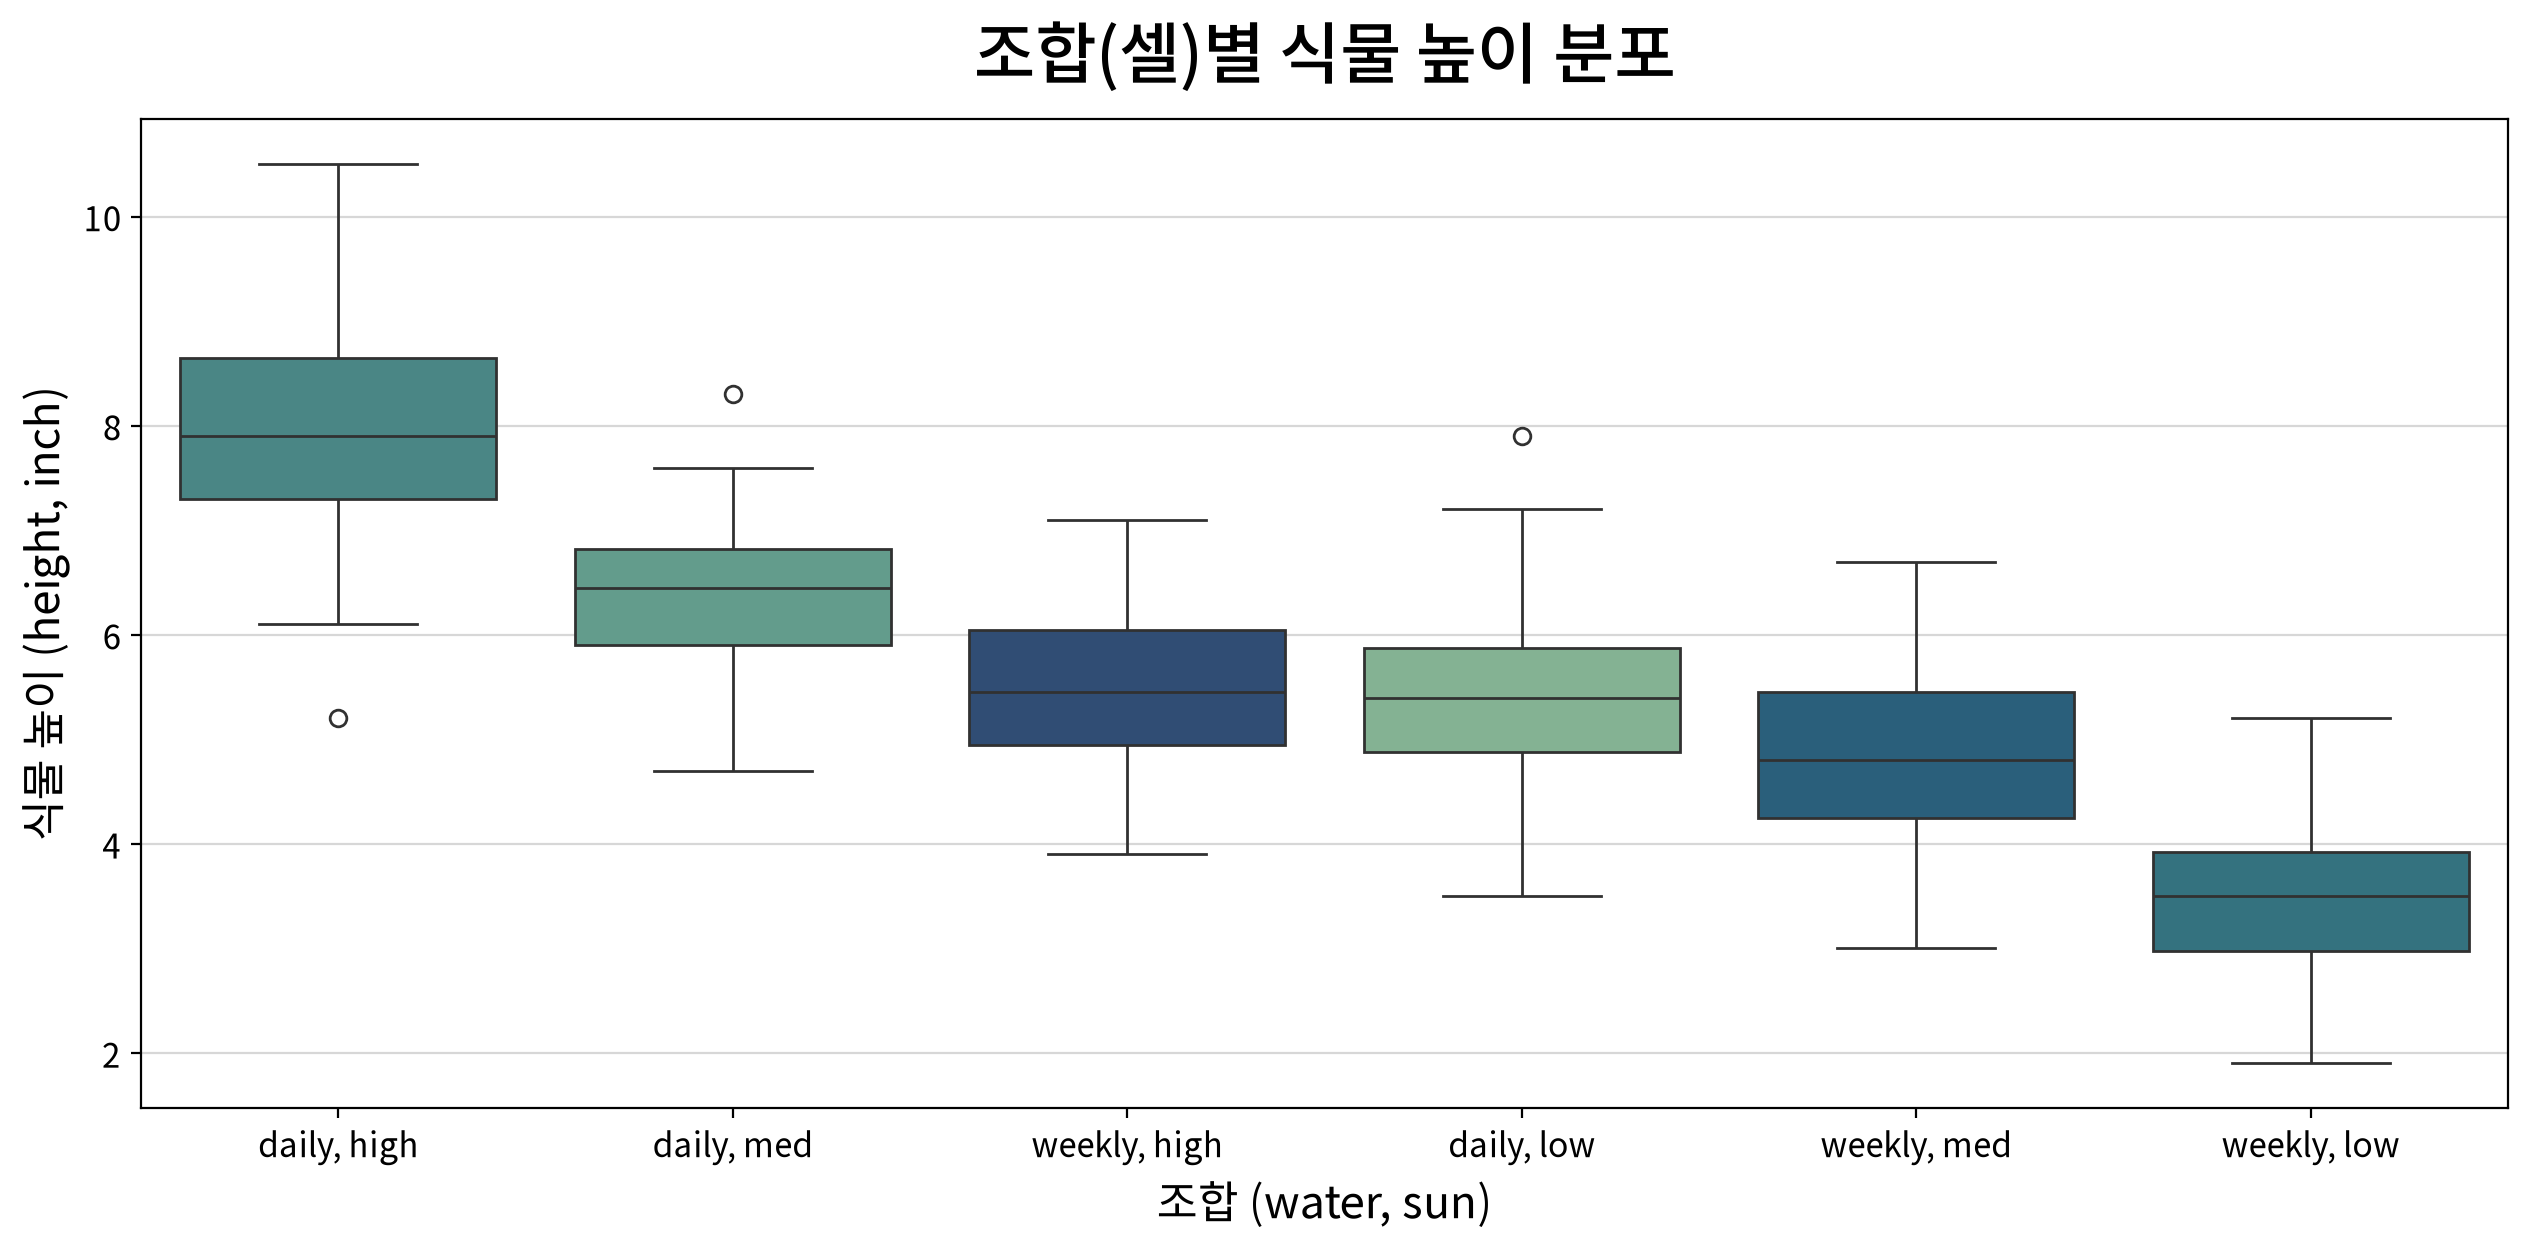

In [50]:
my_plot.boxplot(data=ph, x='group', y='height', order=order, palette='crest', 
                       title='조합(셀)별 식물 높이 분포',
                       xlabel='조합 (water, sun)',
                       ylabel='식물 높이 (height, inch)')

## #05. 모듈화 기능 확인

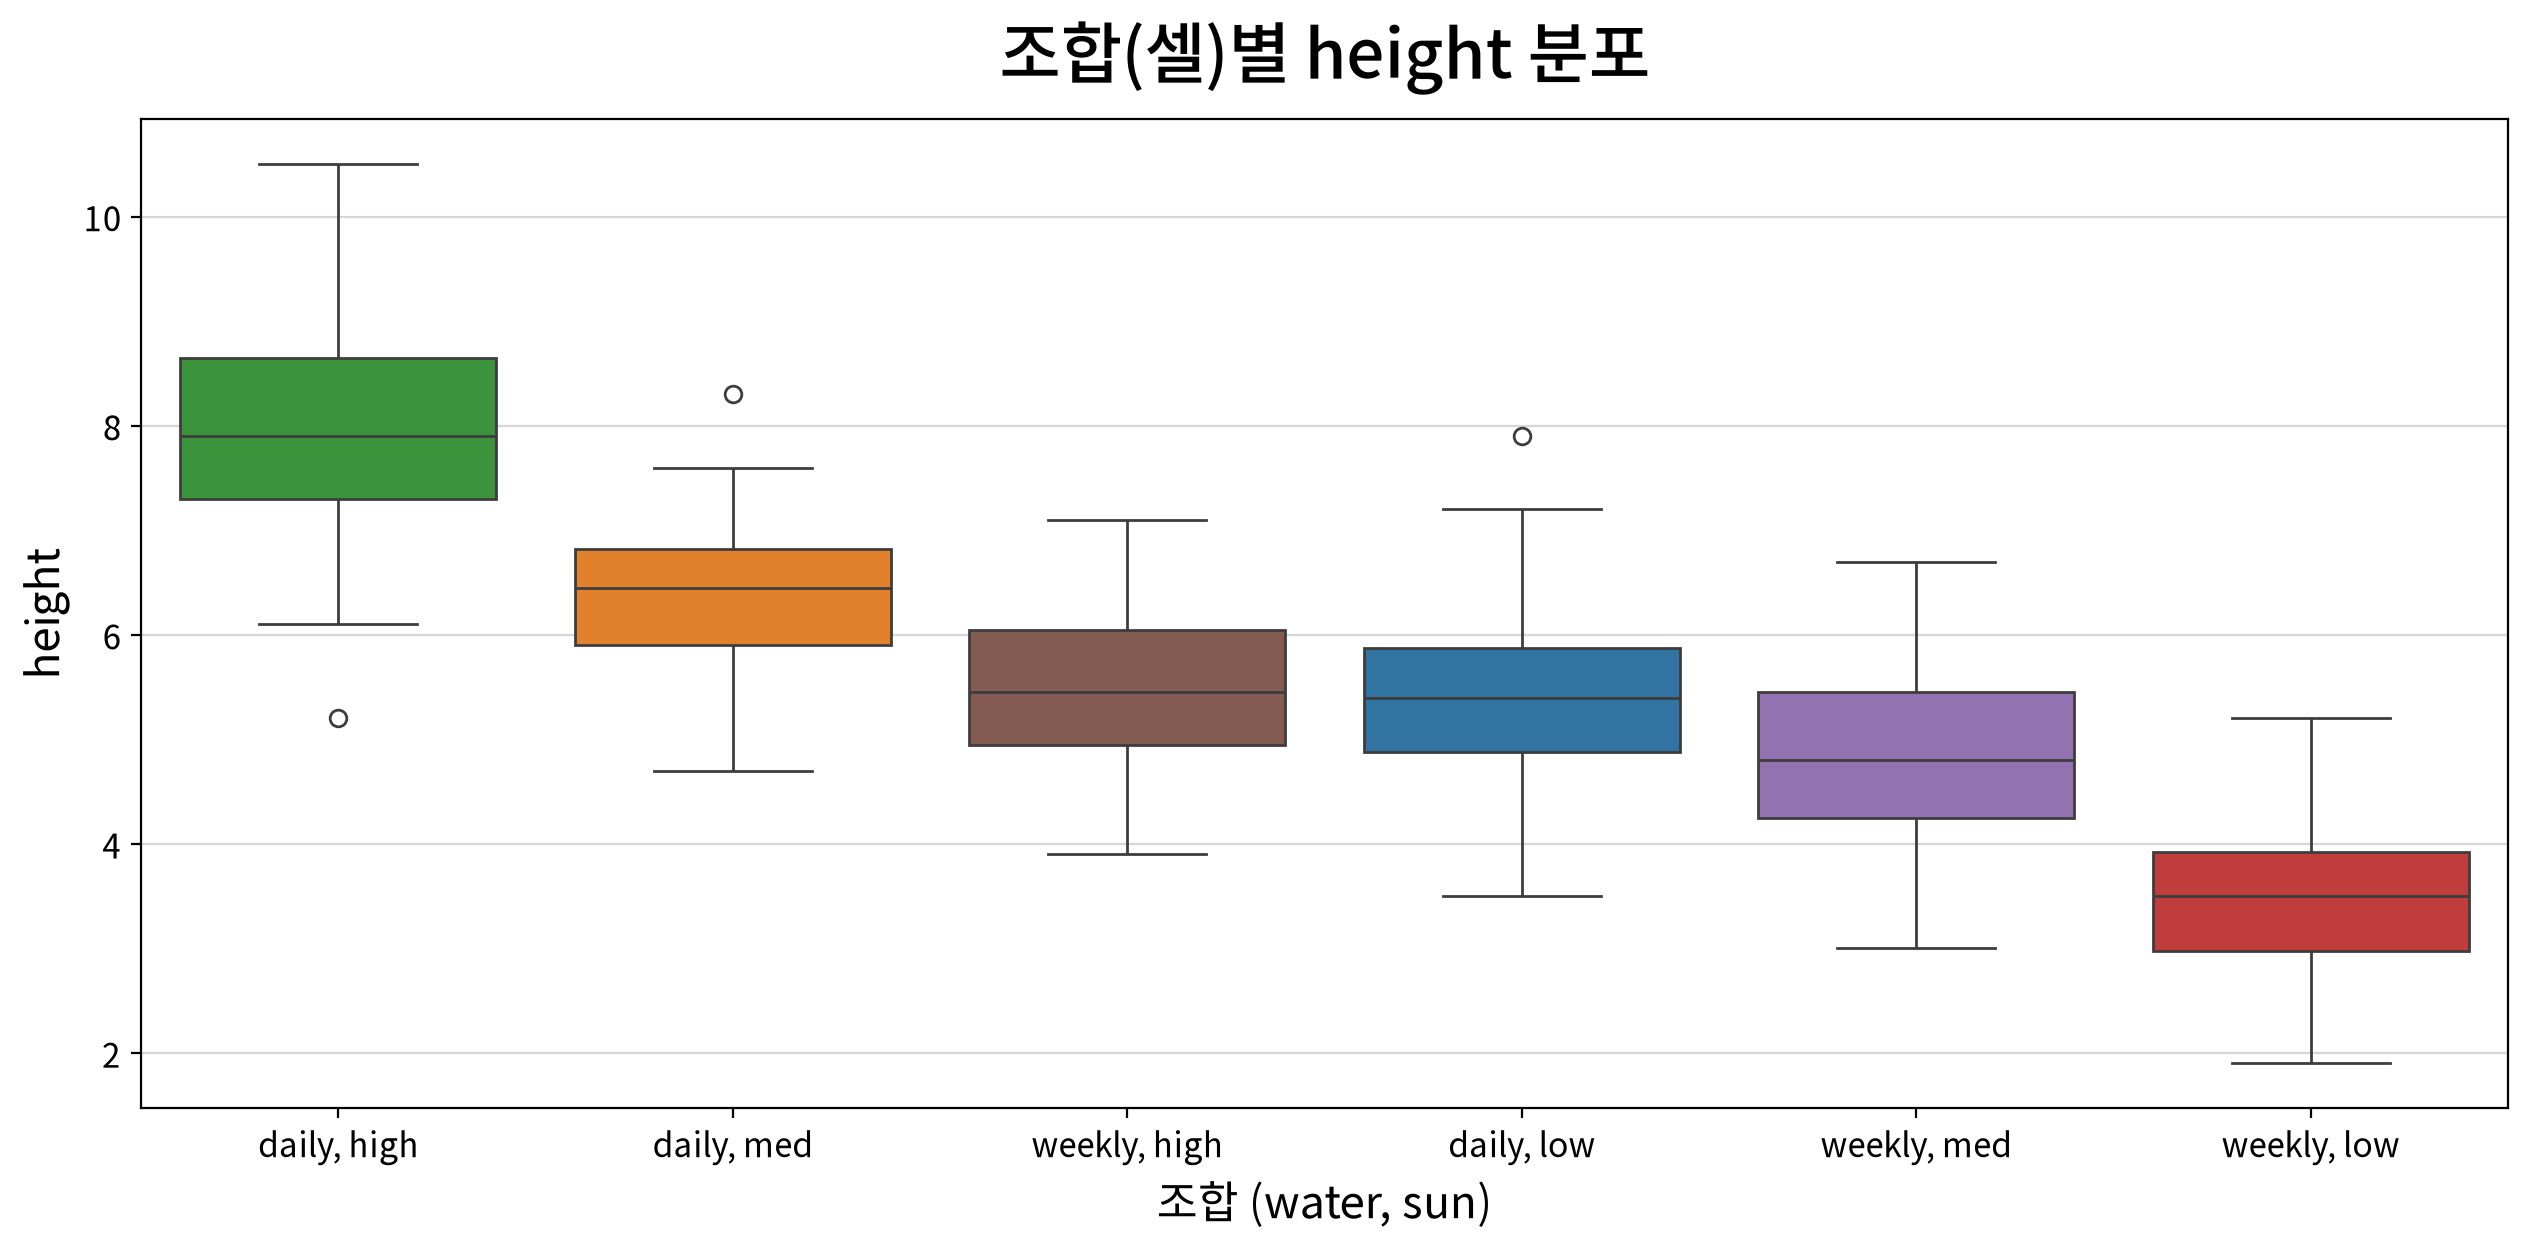

비교한 조합 쌍: 15개
유의한 쌍: 12개
평균 차이가 가장 큰 쌍: (daily, high) vs (weekly, low) → 차이 4.525, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (daily, low) vs (weekly, high) → 차이 0.020, 효과크기 Negligible, p-value 1.000

[daily] 3쌍 중 유의한 쌍: 3개
          A          B   diff  pval  significant
daily, high daily, low  2.515 0.000         True
daily, high daily, med  1.585 0.000         True
 daily, low daily, med -0.930 0.035         True

[weekly] 3쌍 중 유의한 쌍: 2개
           A           B   diff  pval  significant
weekly, high weekly, low  2.030 0.000         True
 weekly, low weekly, med -1.375 0.000         True


,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,"daily, high","daily, low",7.980,5.465,2.515,0.307,8.199,0.000,2.165,True,Large
1,Tukey HSD,"daily, high","daily, med",7.980,6.395,1.585,0.307,5.167,0.000,1.488,True,Large
2,Tukey HSD,"daily, high","weekly, high",7.980,5.485,2.495,0.307,8.134,0.000,2.288,True,Large
3,Tukey HSD,"daily, high","weekly, low",7.980,3.455,4.525,0.307,14.752,0.000,4.216,True,Large
4,Tukey HSD,"daily, high","weekly, med",7.980,4.830,3.150,0.307,10.269,0.000,2.831,True,Large
5,Tukey HSD,"daily, low","daily, med",5.465,6.395,-0.930,0.307,-3.032,0.035,-0.969,True,Large
6,Tukey HSD,"daily, low","weekly, high",5.465,5.485,-0.020,0.307,-0.065,1.000,-0.020,False,Negligible
7,Tukey HSD,"daily, low","weekly, low",5.465,3.455,2.010,0.307,6.553,0.000,2.074,True,Large
8,Tukey HSD,"daily, low","weekly, med",5.465,4.830,0.635,0.307,2.070,0.310,0.627,False,Medium
9,Tukey HSD,"daily, med","weekly, high",6.395,5.485,0.910,0.307,2.967,0.042,1.043,True,Large


In [51]:
my_stats.posthoc_twoway(origin, y='height', 
                    between=['water', 'sun'], palette='tab10')